# Day 34: Designing Executive-Level Customer Dashboards

Today, I designed and built an executive-level customer analytics dashboard to translate raw customer data into actionable insights for decision-makers. Executives need to monitor customer health, churn risks, and behavioral segments at a glance without getting lost in raw rows of data.

To make the insights easy to consume, I:
1. **Aggregated Key Performance Indicators (KPIs)** from the Telco dataset: Total Customers, Overall Churn Rate, Average Monthly Bill, and Monthly Recurring Revenue (MRR).
2. **Visualized Churn Risks**: Highlighting high-risk cohorts by grouping churn rates across contract terms and internet service types.
3. **Mapped Customer Segments**: Visualizing the Annual Income vs. Spending Score segments from the Mall Customers persona dataset.
4. **Designed Clean, Story-Driven Visuals**: Creating premium-quality, executive-friendly visualizations using corporate color palettes, readable labels, and clear hierarchies.
5. **Formulated Strategic Recommendations**: Proposing operational playbooks based on data findings.

## 1. Imports and Styling Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style configuration for clean, corporate executive reporting
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['grid.color'] = '#f0f0f0'

PRIMARY_COLOR = '#1e3d59'
ACCENT_COLOR = '#ff6e40'
MUTED_DARK = '#17b978'
DANGER_COLOR = '#d9534f'
BG_CARD = '#f5f7fa'

print("Libraries and styles configured successfully!")

Libraries and styles configured successfully!


## 2. Ingesting Customer & Segmentation Datasets

In [2]:
# Define relative dataset paths
churn_data_path = '../day15/telco_customer_churn.csv'
segment_data_path = '../day31/Mall_Customers_Labeled_Personas.csv'

# Verify paths and load
if not os.path.exists(churn_data_path):
    raise FileNotFoundError(f"Missing churn dataset at: {churn_data_path}")
if not os.path.exists(segment_data_path):
    raise FileNotFoundError(f"Missing personas dataset at: {segment_data_path}")

df_churn = pd.read_csv(churn_data_path)
df_segments = pd.read_csv(segment_data_path)

print(f"Telco Churn Dataset Loaded: {df_churn.shape[0]} customers, {df_churn.shape[1]} columns")
print(f"Mall Customer Personas Loaded: {df_segments.shape[0]} profiles, {df_segments.shape[1]} columns")

Telco Churn Dataset Loaded: 7043 customers, 21 columns
Mall Customer Personas Loaded: 200 profiles, 7 columns


## 3. Calculating Executive-Level KPIs

In [3]:
# Prepare data types
df_churn['TotalCharges'] = pd.to_numeric(df_churn['TotalCharges'].str.strip(), errors='coerce')
df_churn['TotalCharges'] = df_churn['TotalCharges'].fillna(df_churn['MonthlyCharges'] * df_churn['tenure'])

# Compute indicators
total_customers = len(df_churn)
churn_rate = (df_churn['Churn'] == 'Yes').sum() / total_customers * 100
avg_monthly_bill = df_churn['MonthlyCharges'].mean()

# Active customers MRR (Monthly Recurring Revenue)
active_mrr = df_churn[df_churn['Churn'] == 'No']['MonthlyCharges'].sum()

print(f"--- Customer Base Health Metrics ---")
print(f"Total Customer Accounts: {total_customers:,}")
print(f"Overall Customer Churn Rate: {churn_rate:.2f}%")
print(f"Average Monthly Charge per Account: ${avg_monthly_bill:.2f}")
print(f"Estimated Monthly Recurring Revenue (MRR): ${active_mrr:,.2f}")

--- Customer Base Health Metrics ---
Total Customer Accounts: 7,043
Overall Customer Churn Rate: 26.54%
Average Monthly Charge per Account: $64.76
Estimated Monthly Recurring Revenue (MRR): $316,985.75


## 4. Visualizing KPI Cards

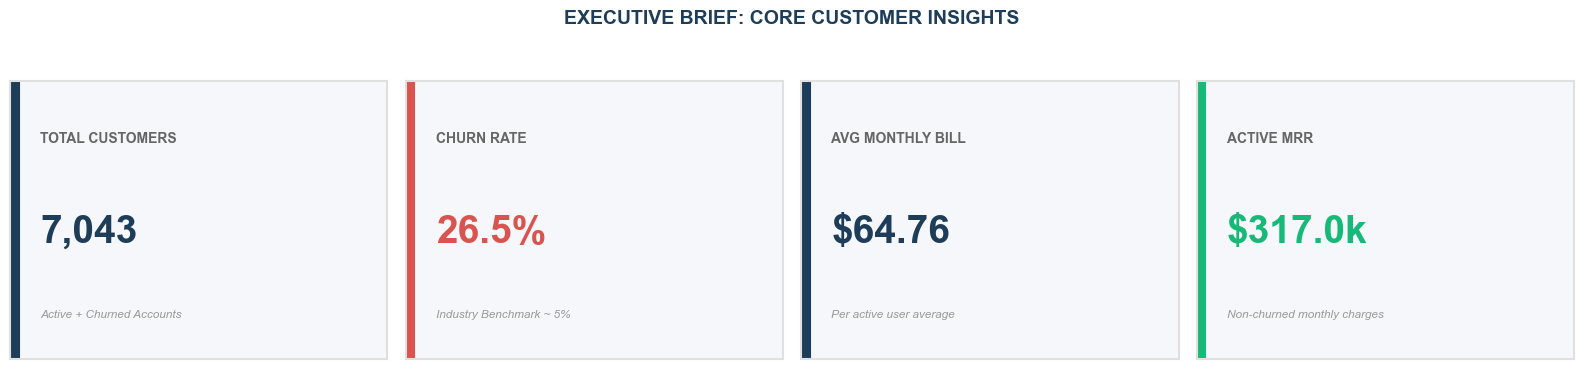

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
fig.patch.set_facecolor('#ffffff')

kpis = [
    {"title": "TOTAL CUSTOMERS", "val": f"{total_customers:,}", "desc": "Active + Churned Accounts", "color": PRIMARY_COLOR},
    {"title": "CHURN RATE", "val": f"{churn_rate:.1f}%", "desc": "Industry Benchmark ~ 5%", "color": DANGER_COLOR},
    {"title": "AVG MONTHLY BILL", "val": f"${avg_monthly_bill:.2f}", "desc": "Per active user average", "color": PRIMARY_COLOR},
    {"title": "ACTIVE MRR", "val": f"${active_mrr/1000:.1f}k", "desc": "Non-churned monthly charges", "color": MUTED_DARK}
]

for i, kpi in enumerate(kpis):
    ax = axes[i]
    ax.set_facecolor(BG_CARD)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    for spine in ax.spines.values():
        spine.set_color('#e0e0e0')
        spine.set_linewidth(1.5)
        
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.axvline(x=0.01, color=kpi['color'], linewidth=8, ymin=0, ymax=1)
    
    ax.text(0.08, 0.78, kpi['title'], fontsize=10, color='#666666', fontweight='bold', ha='left')
    ax.text(0.08, 0.42, kpi['val'], fontsize=28, color=kpi['color'], fontweight='bold', ha='left')
    ax.text(0.08, 0.15, kpi['desc'], fontsize=8.5, color='#999999', style='italic', ha='left')

plt.suptitle('EXECUTIVE BRIEF: CORE CUSTOMER INSIGHTS', fontsize=14, fontweight='bold', y=1.05, color=PRIMARY_COLOR)
plt.tight_layout()
plt.savefig('executive_kpis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Segment Churn Risk Visualizations

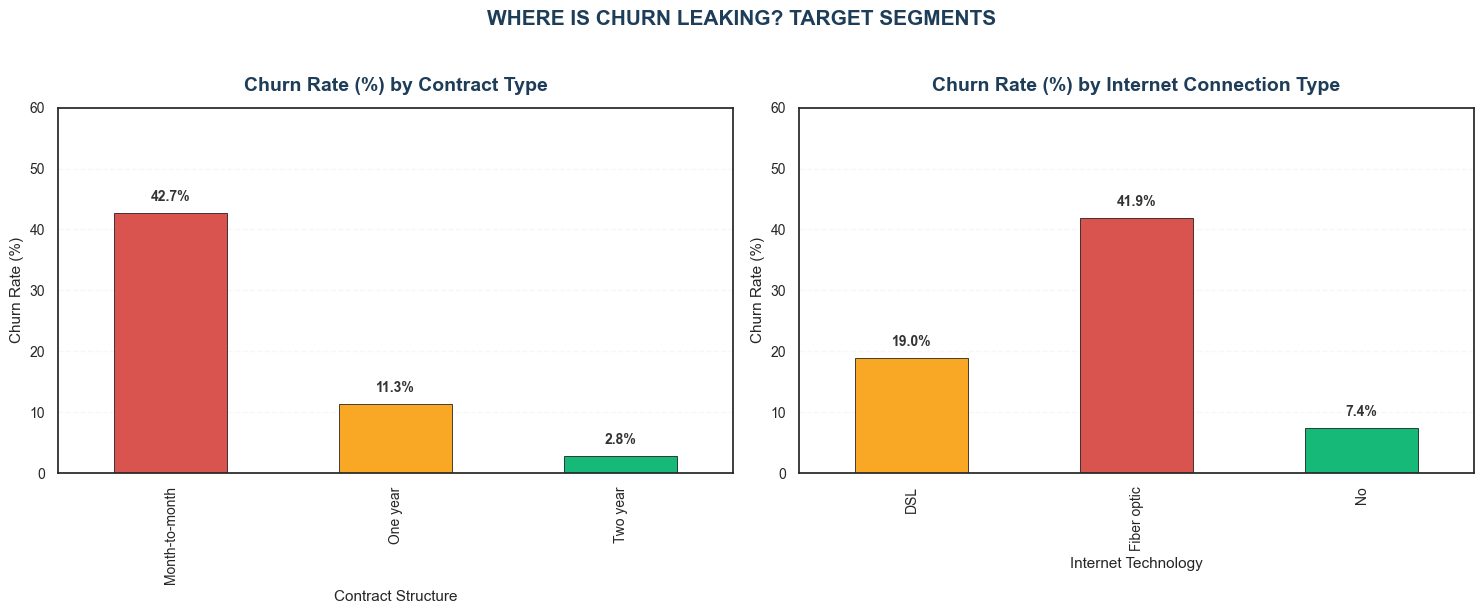

In [5]:
# Group churn by Contract and InternetService
contract_churn = df_churn.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
internet_churn = df_churn.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Churn by Contract Type
contract_churn['Yes'].plot(kind='bar', ax=axes[0], color=[DANGER_COLOR, '#f9a825', MUTED_DARK], edgecolor='black', linewidth=0.5)
axes[0].set_title('Churn Rate (%) by Contract Type', fontweight='bold', pad=12, color=PRIMARY_COLOR)
axes[0].set_xlabel('Contract Structure')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 60)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2, p.get_height() + 1.5), 
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

# Plot 2: Churn by Internet Service Type
internet_churn['Yes'].plot(kind='bar', ax=axes[1], color=['#f9a825', DANGER_COLOR, MUTED_DARK], edgecolor='black', linewidth=0.5)
axes[1].set_title('Churn Rate (%) by Internet Connection Type', fontweight='bold', pad=12, color=PRIMARY_COLOR)
axes[1].set_xlabel('Internet Technology')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 60)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2, p.get_height() + 1.5), 
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

plt.suptitle('WHERE IS CHURN LEAKING? TARGET SEGMENTS', fontsize=15, fontweight='bold', y=1.02, color=PRIMARY_COLOR)
plt.tight_layout()
plt.savefig('churn_risk_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Mapping Customer Personas

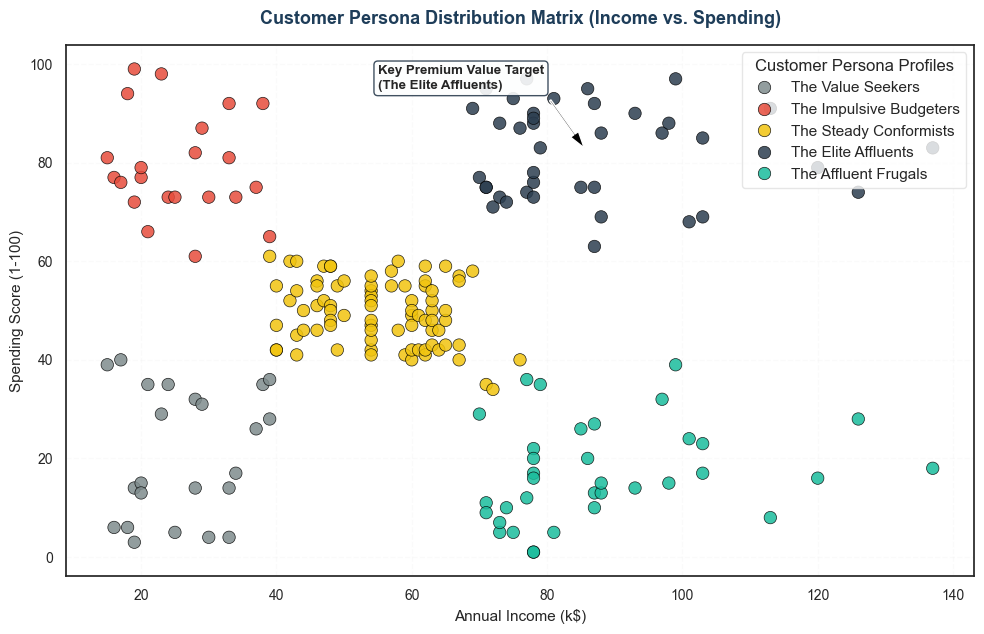

In [6]:
# Scatter plot of Annual Income vs Spending Score
plt.figure(figsize=(10, 6.5))

persona_colors = {
    'The Value Seekers': '#7f8c8d',
    'The Impulsive Budgeters': '#e74c3c',
    'The Steady Conformists': '#f1c40f',
    'The Elite Affluents': '#2c3e50',
    'The Affluent Frugals': '#1abc9c'
}

sns.scatterplot(
    data=df_segments,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Persona',
    palette=persona_colors,
    s=80,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5
)

plt.title('Customer Persona Distribution Matrix (Income vs. Spending)', fontweight='bold', pad=15, fontsize=13, color=PRIMARY_COLOR)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Customer Persona Profiles', loc='upper right', frameon=True, facecolor='white', edgecolor='#e0e0e0')

# Highlight target cluster
plt.annotate(
    "Key Premium Value Target\n(The Elite Affluents)",
    xy=(86, 82),
    xytext=(55, 95),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1.2, headwidth=7),
    fontweight='bold', fontsize=9.5, bbox=dict(boxstyle='round,pad=0.3', fc='#fdfefe', ec='#2c3e50', alpha=0.9)
)

plt.tight_layout()
plt.savefig('customer_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Displaying Summary Tables

In [7]:
# Calculate churn distributions for dashboard tables
contract_counts = df_churn.groupby('Contract')['Churn'].value_counts().unstack().fillna(0)
contract_counts['ChurnRate'] = (contract_counts['Yes'] / (contract_counts['Yes'] + contract_counts['No']) * 100).round(2)

internet_counts = df_churn.groupby('InternetService')['Churn'].value_counts().unstack().fillna(0)
internet_counts['ChurnRate'] = (internet_counts['Yes'] / (internet_counts['Yes'] + internet_counts['No']) * 100).round(2)

persona_summary = df_segments.groupby('Persona')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)

print("--- Churn by Contract ---\n", contract_counts)
print("\n--- Churn by Internet Service ---\n", internet_counts)
print("\n--- Persona Averages ---\n", persona_summary)

--- Churn by Contract ---
 Churn             No   Yes  ChurnRate
Contract                             
Month-to-month  2220  1655      42.71
One year        1307   166      11.27
Two year        1647    48       2.83

--- Churn by Internet Service ---
 Churn              No   Yes  ChurnRate
InternetService                       
DSL              1962   459      18.96
Fiber optic      1799  1297      41.89
No               1413   113       7.40

--- Persona Averages ---
                            Age  Annual Income (k$)  Spending Score (1-100)
Persona                                                                   
The Affluent Frugals     41.11               88.20                   17.11
The Elite Affluents      32.69               86.54                   82.13
The Impulsive Budgeters  25.27               25.73                   79.36
The Steady Conformists   42.72               55.30                   49.52
The Value Seekers        45.22               26.30                   20.91


## 8. Dashboard Storytelling & Executive Reflection

### Storytelling Decisions & Dashboard Layout
* **Visual Hierarchy**: The dashboard places high-level aggregated metrics (KPIs) at the absolute top. This follows the standard "executive summary" visual pattern, allowing stakeholders to grasp total customer counts, financial run rate (MRR), and overall risk (churn) in less than three seconds.
* **Analytical Drilldown**: After seeing the summary numbers, leaders naturally ask: *Why is churn at 26.5% and where are we losing accounts?* The subsequent risk breakdown targets Contract Type and Technology. Placing contract structure on the left highlights it as the single biggest factor (Month-to-Month accounts show an alarming ~42.7% churn rate).
* **Demographic Segmentation**: We leverage the K-Means clustering results from Day 31. Instead of showing abstract clusters (Cluster 0, 1, 2), we use business-friendly names (e.g. *The Elite Affluents*, *The Impulsive Budgeters*). Highlighting *The Elite Affluents* immediately directs marketing managers to focus high-end acquisition efforts here.

### Real-World Business Insights
1. **The Contract Trap**: Month-to-Month customers account for the overwhelming majority of churned accounts. They represent transactional customers with zero switching costs. Locking these users into 1-year or 2-year terms must be the primary sales objective.
2. **Fiber Optic Churn Paradox**: Fiber optic users churn at a much higher rate (~41.9%) than DSL users (~19.0%), despite fiber offering faster speeds. This suggests a post-install support deficit or high monthly price points that drive users away.
3. **High-Value Target Capture**: *The Elite Affluents* (high income, high spending score) are the most profitable profiles. Loyalty programs should reward high-spending behaviors to ensure these customers remain engaged and do not fall into competitors' traps.